# Counterfeit detection

The task in this assignment is to detect the  counterfeit banknotes. The data set is based on [banknote authentication Data Set ](https://archive.ics.uci.edu/ml/datasets/banknote+authentication#) from UCI Machine Learning repository. The first three columns denote different parameters obtained from the photographs of the banknotes and last colum provides the label. Frankly as the dataset does not have any description I don't know  which labels corresponds to real and which to counterfeited banknotes. let's assume that label one (positive) denotes the clounterfeits. The set  [banknote_authentication.csv](./data/banknote_authentication.csv) can be found in the `data`  directory.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as st

In [7]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

In [8]:
import  matplotlib.pyplot as plt
plt.rcParams['figure.figsize']=(8,8)

Please insert you  firstname  and name below

In [9]:
from  sklearn.model_selection import train_test_split
seed = 31287

In [10]:
data = pd.read_csv('data/banknotes_data.csv')

In [11]:
data.head()

,a0,a1,a2,a3,counterfeit
0,-1.1306,1.8458,-1.35750,-1.38060,1
1,-1.1188,3.3357,-1.34550,-1.95730,1
2,2.6719,3.0646,0.37158,0.58619,0
3,-4.1409,3.4619,-0.47841,-3.88790,1
4,1.4507,8.7903,-2.23240,-0.65259,0


In [12]:
data.describe()

,a0,a1,a2,a3,counterfeit
count,1166.000000,1166.000000,1166.000000,1166.000000,1166.000000
mean,0.431116,1.902054,1.426607,-1.220393,0.444254
std,2.845672,5.942260,4.397341,2.101777,0.497096
min,-7.042100,-13.773100,-5.286100,-7.871900,0.000000
25%,-1.770900,-1.916200,-1.664300,-2.466150,0.000000
50%,0.471345,2.408650,0.567365,-0.614450,0.000000
75%,2.816925,6.800675,3.338825,0.394810,1.000000
max,6.824800,12.730200,17.927400,2.449500,1.000000


In [13]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1166 entries, 0 to 1165
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   a0           1166 non-null   float64
 1   a1           1166 non-null   float64
 2   a2           1166 non-null   float64
 3   a3           1166 non-null   float64
 4   counterfeit  1166 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 45.7 KB


In [14]:
data_train, data_test = train_test_split(data, test_size=0.2, shuffle=True, stratify=data.loc[:,'counterfeit'], random_state=seed)

In [15]:
data_train

,a0,a1,a2,a3,counterfeit
711,1.94760,-4.773800,8.52700,-1.866800,0
565,1.42760,8.384700,-2.09950,-1.967700,0
912,-4.28590,8.523400,3.13920,-0.916390,0
64,4.92490,0.689060,0.77344,1.209500,0
871,2.19480,1.378100,1.15820,0.857740,0
...,...,...,...,...,...
47,-2.45610,-4.556600,6.45340,-0.056479,1
1161,1.21380,8.798600,-2.16720,-0.741820,0
174,5.87820,5.940900,-2.85440,-0.608630,0
1119,0.17346,7.869500,0.26876,-3.788300,0


In [16]:
lbls_train = data_train['counterfeit']
lbls_test = data_test['counterfeit']

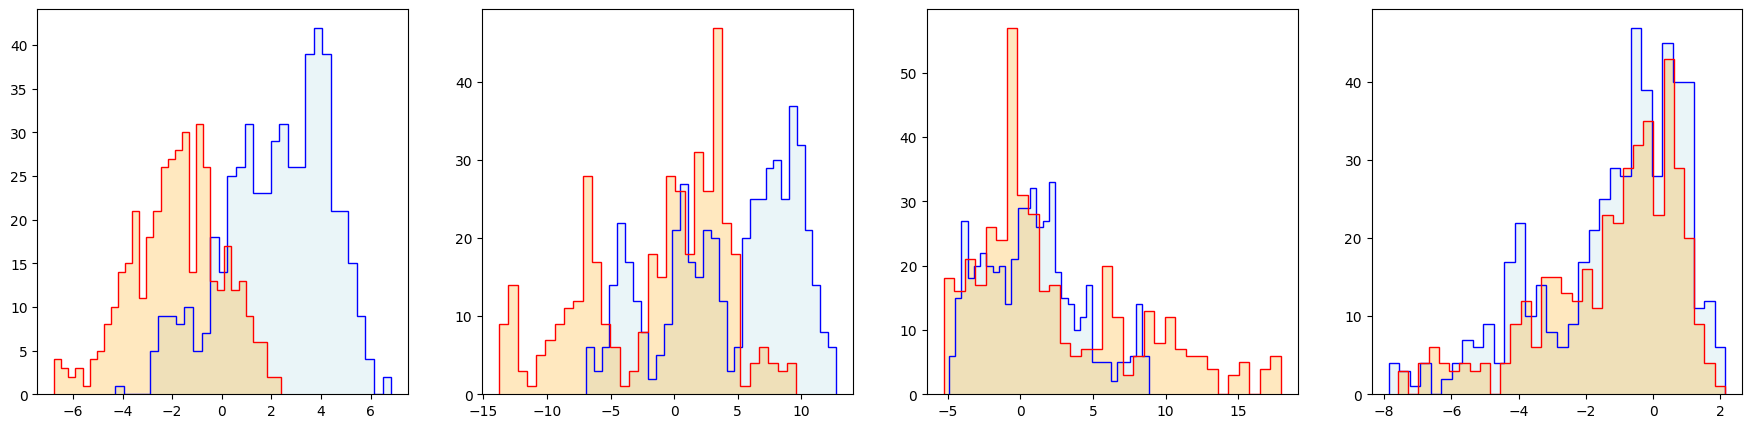

In [17]:
fig, ax = plt.subplots(1,4, figsize=(22,5))
for i in range(4):
    ax[i].hist(data_train[lbls_train==0].iloc[:,i], bins=32, histtype='step', color='blue')
    ax[i].hist(data_train[lbls_train==1].iloc[:,i], bins=32, histtype='step', color='red')
    ax[i].hist(data_train[lbls_train==0].iloc[:,i], bins=32, histtype='bar', color='lightblue', alpha=0.25)
    ax[i].hist(data_train[lbls_train==1].iloc[:,i], bins=32, histtype='bar', color='orange', alpha =0.25)

## Problem 2

Using the GaussianNB function construct the Gaussian Bayes classifier using two features. Calculate the confusion matrix (normalized as to show rates), ROC AUC score and plot ROC curve. Do this both for training and validation set. Plot both curves on the same plot. Additionally, on the test set, compare ROC curve obtained with this 2-features classifier and  1-features classifier (the one from Problem 1, previous classes). What is the improvement of AUC score on the test set when we use 2-features classifier instead of 1-features classifier?

Train AUC (2 features): 0.9500
Test AUC  (2 features): 0.9638
Test AUC  (1 feature) : 0.9443
AUC improvement        : 0.0195


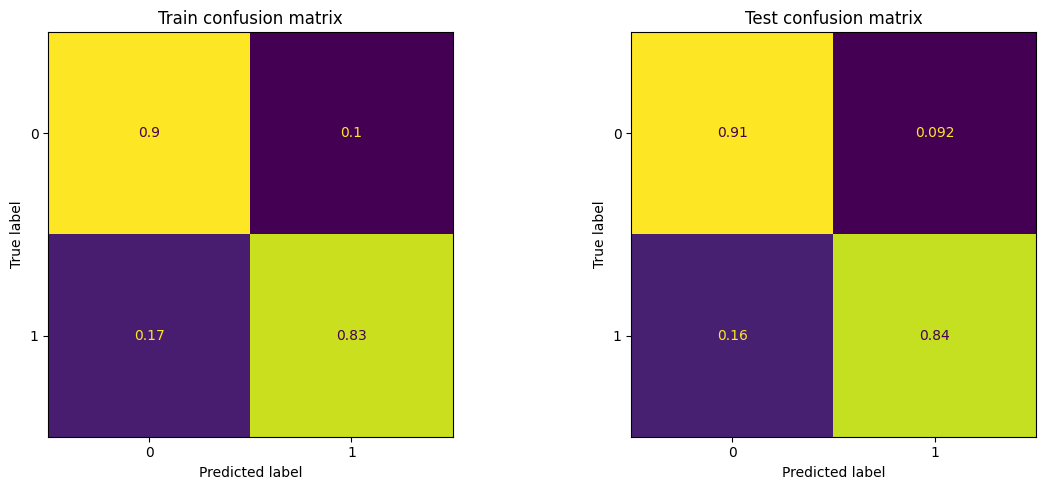

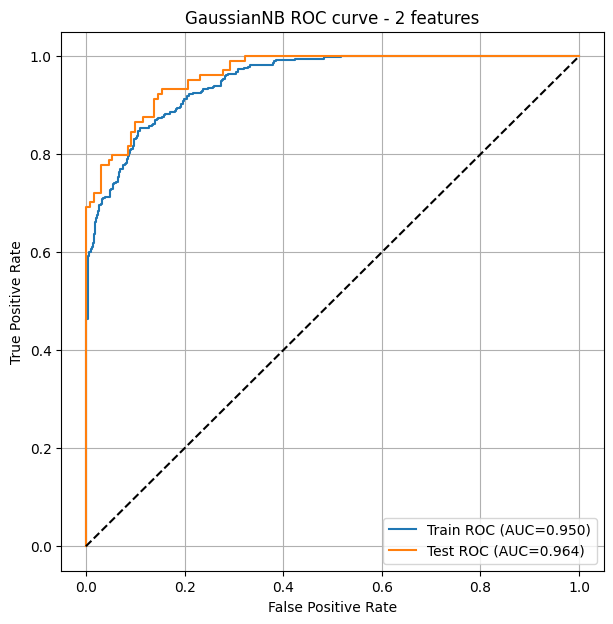

In [21]:

from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score
)

feature_cols = [c for c in data.columns if c != 'counterfeit']

X_train_a0 = data_train[[feature_cols[0]]]
X_test_a0 = data_test[[feature_cols[0]]]

X_train_a0a1 = data_train[feature_cols[:2]]
X_test_a0a1 = data_test[feature_cols[:2]]

y_train = lbls_train
y_test = lbls_test

gnb_a0 = GaussianNB()
gnb_a0.fit(X_train_a0, y_train)

gnb_a0a1 = GaussianNB()
gnb_a0a1.fit(X_train_a0a1, y_train)

y_pred_train_a0a1 = gnb_a0a1.predict(X_train_a0a1)
y_pred_test_a0a1 = gnb_a0a1.predict(X_test_a0a1)

y_score_train_a0 = gnb_a0.predict_proba(X_train_a0)[:,1]
y_score_test_a0 = gnb_a0.predict_proba(X_test_a0)[:,1]

y_score_train_a0a1 = gnb_a0a1.predict_proba(X_train_a0a1)[:,1]
y_score_test_a0a1 = gnb_a0a1.predict_proba(X_test_a0a1)[:,1]

fprs_train_a0a1, tprs_train_a0a1, _ = roc_curve(y_train, y_score_train_a0a1)
fprs_test_a0a1, tprs_test_a0a1, _ = roc_curve(y_test, y_score_test_a0a1)

fprs_test_a0, tprs_test_a0, _ = roc_curve(y_test, y_score_test_a0)

auc_train_a0a1 = roc_auc_score(y_train, y_score_train_a0a1)
auc_test_a0a1 = roc_auc_score(y_test, y_score_test_a0a1)

auc_test_a0 = roc_auc_score(y_test, y_score_test_a0)

print(f"Train AUC (2 features): {auc_train_a0a1:.4f}")
print(f"Test AUC  (2 features): {auc_test_a0a1:.4f}")
print(f"Test AUC  (1 feature) : {auc_test_a0:.4f}")
print(f"AUC improvement        : {auc_test_a0a1 - auc_test_a0:.4f}")

fig, ax = plt.subplots(1,2, figsize=(12,5))

cm_train = confusion_matrix(y_train, y_pred_train_a0a1, normalize='true')
cm_test = confusion_matrix(y_test, y_pred_test_a0a1, normalize='true')

ConfusionMatrixDisplay(cm_train).plot(ax=ax[0], colorbar=False)
ax[0].set_title("Train confusion matrix")

ConfusionMatrixDisplay(cm_test).plot(ax=ax[1], colorbar=False)
ax[1].set_title("Test confusion matrix")

plt.tight_layout()
plt.show()

plt.figure(figsize=(7,7))
plt.plot(fprs_train_a0a1, tprs_train_a0a1,
         label=f"Train ROC (AUC={auc_train_a0a1:.3f})")
plt.plot(fprs_test_a0a1, tprs_test_a0a1,
         label=f"Test ROC (AUC={auc_test_a0a1:.3f})")

plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("GaussianNB ROC curve - 2 features")
plt.legend()
plt.grid()
plt.show()


## Problem 3

Same as Problem 2 but now implement Gaussian Naive Bayes using all features. Show confusion matrix only for test set. Compare all three ROC curves on the test set, same with AUC score.

Test AUC (all features): 0.9521


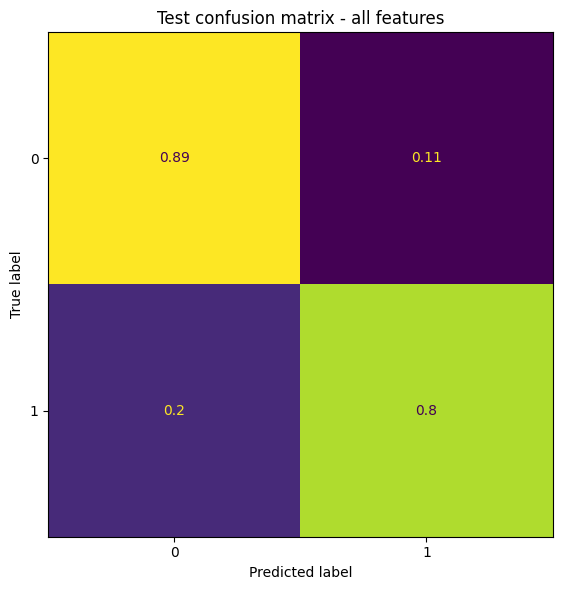

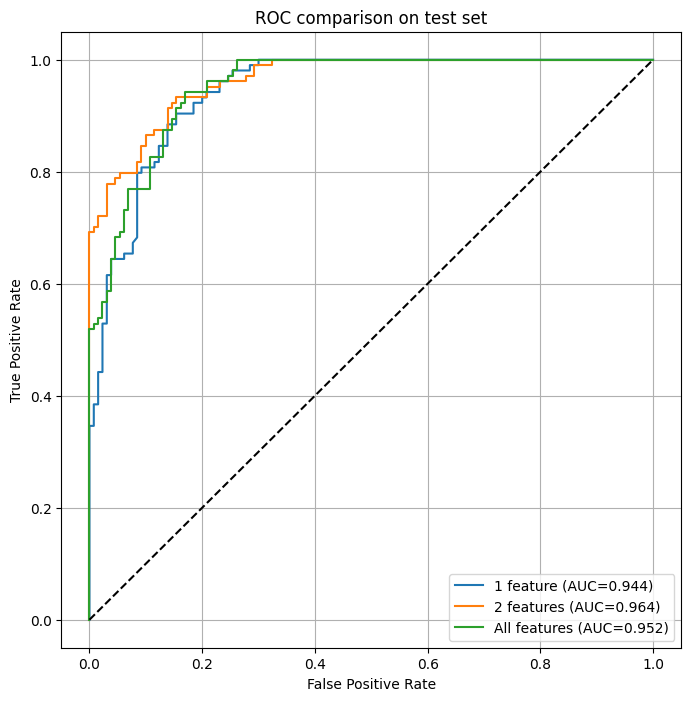

In [23]:

X_train_all = data_train[feature_cols]
X_test_all = data_test[feature_cols]

gnb_all = GaussianNB()
gnb_all.fit(X_train_all, y_train)

y_pred_test_all = gnb_all.predict(X_test_all)

y_score_test_all = gnb_all.predict_proba(X_test_all)[:,1]

fprs_test_all, tprs_test_all, _ = roc_curve(y_test, y_score_test_all)

auc_test_all = roc_auc_score(y_test, y_score_test_all)

print(f"Test AUC (all features): {auc_test_all:.4f}")

fig, ax = plt.subplots(figsize=(6,6))

cm_test_all = confusion_matrix(y_test, y_pred_test_all, normalize='true')

ConfusionMatrixDisplay(cm_test_all).plot(ax=ax, colorbar=False)
ax.set_title("Test confusion matrix - all features")

plt.tight_layout()
plt.show()

plt.figure(figsize=(8,8))

plt.plot(fprs_test_a0, tprs_test_a0,
         label=f"1 feature (AUC={auc_test_a0:.3f})")

plt.plot(fprs_test_a0a1, tprs_test_a0a1,
         label=f"2 features (AUC={auc_test_a0a1:.3f})")

plt.plot(fprs_test_all, tprs_test_all,
         label=f"All features (AUC={auc_test_all:.3f})")

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC comparison on test set")
plt.legend()
plt.grid()
plt.show()


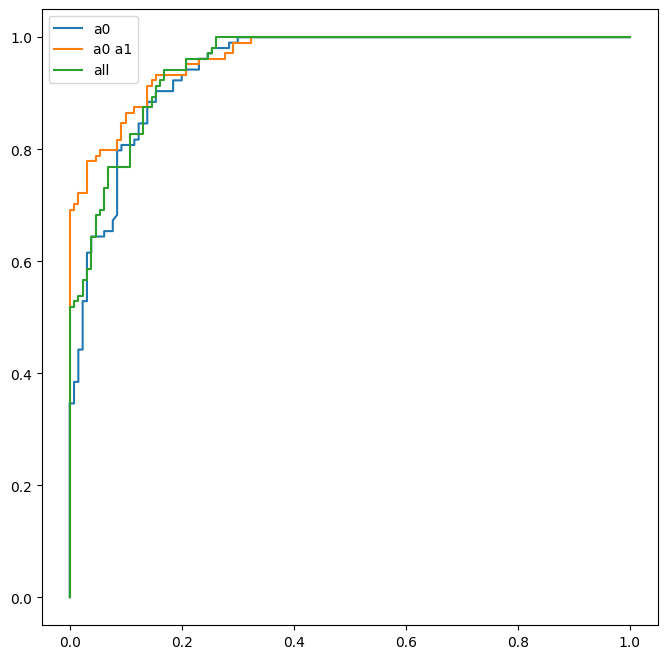

In [24]:
fig, ax = plt.subplots(figsize=(8,8))
ax.set_aspect(1.0)
plt.plot(fprs_test_a0, tprs_test_a0,label='a0');
plt.plot(fprs_test_a0a1, tprs_test_a0a1,label='a0 a1');
plt.plot(fprs_test_all, tprs_test_all,label='all');
plt.legend();